In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
import librosa.display
import yaml
from IPython.display import Audio, display

ROOT = Path.cwd()
while not (ROOT / "config.yaml").exists():
    ROOT = ROOT.parent
with open(ROOT / "config.yaml") as f:
    CFG = yaml.safe_load(f)
US8K = ROOT / "data" / "raw" / "UrbanSound8K"
KAB  = ROOT / "data" / "raw" / "kabealo"
print("Proje klasoru:", ROOT)

Proje klasoru: c:\proje\gunshot


Toplam dosya: 8732
class
dog_bark            1000
children_playing    1000
air_conditioner     1000
street_music        1000
engine_idling       1000
jackhammer          1000
drilling            1000
siren                929
car_horn             429
gun_shot             374
Name: count, dtype: int64


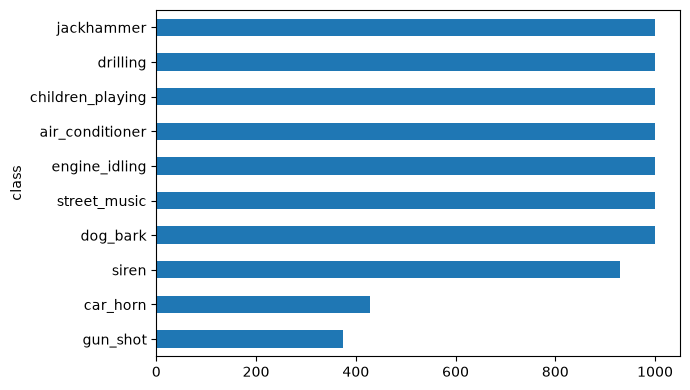

In [2]:
meta = pd.read_csv(US8K / "metadata" / "UrbanSound8K.csv")
meta["path"] = meta.apply(lambda r: US8K / "audio" / f"fold{r.fold}" / r.slice_file_name, axis=1)
meta["duration"] = meta["end"] - meta["start"]
print("Toplam dosya:", len(meta))
print(meta["class"].value_counts())
meta["class"].value_counts().sort_values().plot(kind="barh", figsize=(7, 4))
plt.tight_layout(); plt.show()

In [3]:
infos = [(i.samplerate, i.channels, i.subtype) for i in (sf.info(str(p)) for p in meta["path"])]
meta[["sr", "channels", "subtype"]] = pd.DataFrame(infos, index=meta.index, columns=["sr", "channels", "subtype"])
print(meta["sr"].value_counts(), "\n")
print(meta["channels"].value_counts(), "\n")
print(meta["subtype"].value_counts())

sr
44100     5370
48000     2502
96000      610
24000       82
16000       45
22050       44
11025       39
192000      17
8000        12
11024        7
32000        4
Name: count, dtype: int64 

channels
2    7993
1     739
Name: count, dtype: int64 

subtype
PCM_16       5758
PCM_24       2753
FLOAT         169
PCM_U8         43
MS_ADPCM        8
IMA_ADPCM       1
Name: count, dtype: int64


In [4]:
low = meta[meta["sr"] < 16000]
print(low["class"].value_counts())

class
dog_bark            22
children_playing    15
street_music        12
siren                9
Name: count, dtype: int64


In [6]:
gun = meta[meta["class"] == "gun_shot"]
print("gun_shot:", len(gun), "| farkli kaynak kayit:", gun["fsID"].nunique())
print(gun["fold"].value_counts().sort_index())
print(gun["duration"].describe())

gun_shot: 374 | farkli kaynak kayit: 117
fold
1     35
2     35
3     36
4     38
5     40
6     46
7     51
8     30
9     31
10    32
Name: count, dtype: int64
count    374.000000
mean       1.649188
std        0.902326
min        0.166284
25%        1.009581
50%        1.473688
75%        2.185675
max        4.000000
Name: duration, dtype: float64


In [7]:
for _, r in gun.sample(5).iterrows():
    print(f"{r.slice_file_name} | fold {r.fold} | {r.duration:.2f} sn")
    display(Audio(str(r.path)))

162433-6-1-0.wav | fold 8 | 0.50 sn


157207-6-5-0.wav | fold 10 | 2.08 sn


145612-6-3-0.wav | fold 8 | 1.13 sn


76091-6-0-0.wav | fold 2 | 0.41 sn


148827-6-3-0.wav | fold 7 | 1.02 sn


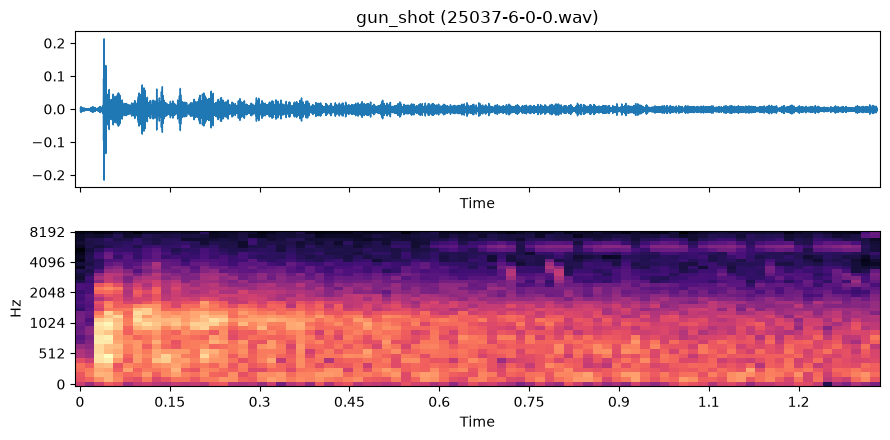

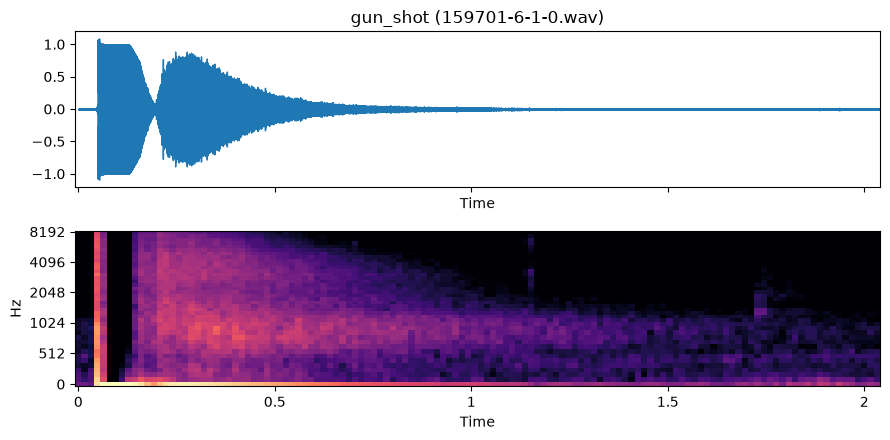

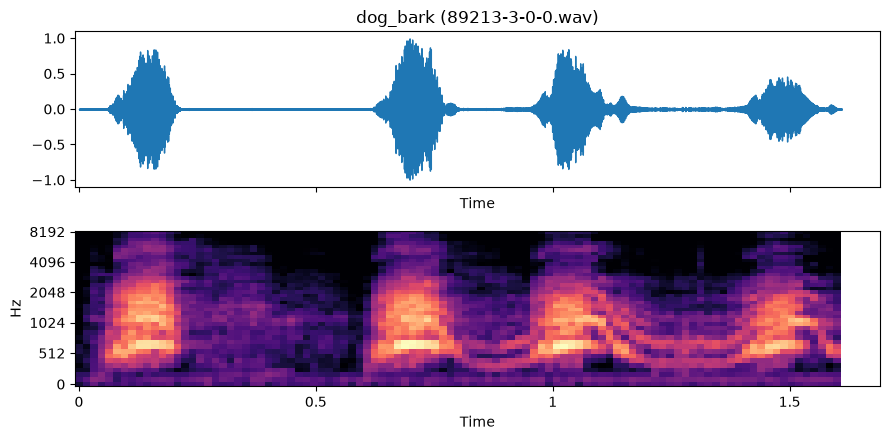

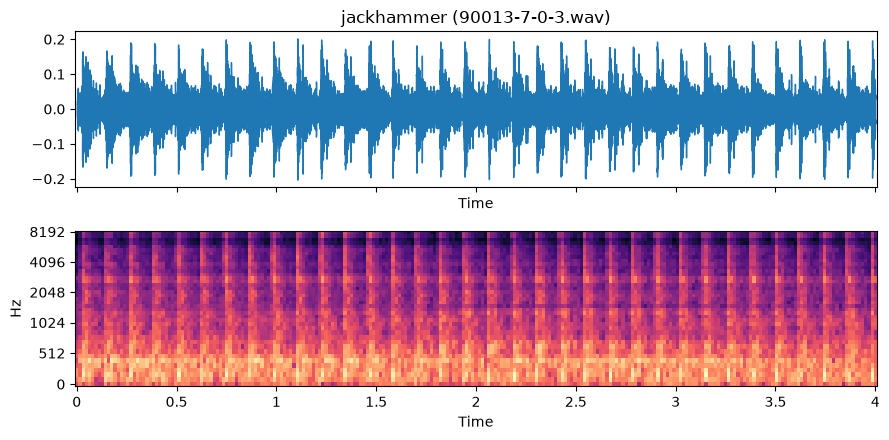

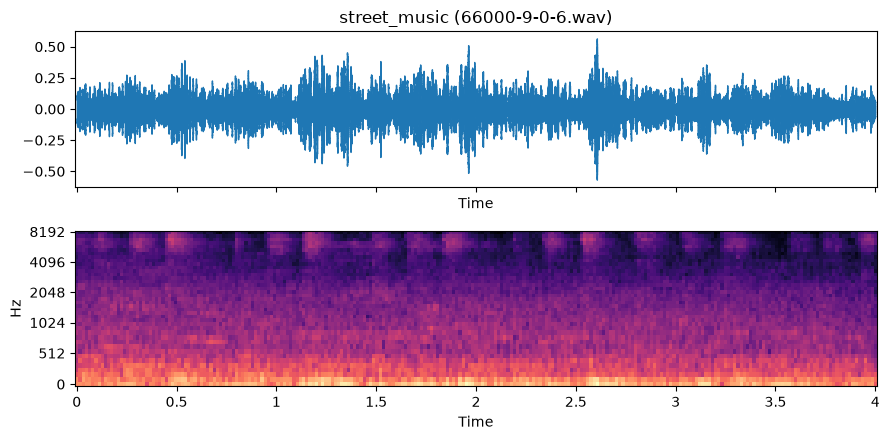

In [8]:
SR, N_FFT, HOP, N_MELS = CFG["sample_rate"], CFG["n_fft"], CFG["hop_length"], CFG["n_mels"]

def show(path, title):
    y, _ = librosa.load(str(path), sr=SR, mono=True)
    S = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS, htk=True)
    fig, ax = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True)
    librosa.display.waveshow(y, sr=SR, ax=ax[0]); ax[0].set_title(title)
    librosa.display.specshow(librosa.power_to_db(S, ref=np.max), sr=SR, hop_length=HOP,
                             x_axis="time", y_axis="mel", ax=ax[1])
    plt.tight_layout(); plt.show()
    display(Audio(y, rate=SR))

for cls in ["gun_shot", "gun_shot", "dog_bark", "jackhammer", "street_music"]:
    r = meta[meta["class"] == cls].sample(1).iloc[0]
    show(r.path, f"{cls} ({r.slice_file_name})")

In [9]:
kmeta = pd.read_csv(KAB / "gunshot-audio-all-metadata.csv")
klabels = pd.read_csv(KAB / "gunshot-audio-labels-only.csv")
print("all-metadata:", kmeta.shape, list(kmeta.columns))
display(kmeta.head(3))
print("labels-only:", klabels.shape, list(klabels.columns))
display(klabels.head(5))
for c in klabels.columns:
    if klabels[c].nunique() <= 20:
        print(f"\n--- {c}\n", klabels[c].value_counts().to_string())

all-metadata: (2148, 16) ['filename', 'uuid', 'label', 'recording_session ', 'timestamp', 'time_offset_s', 'device_name', 'device_manufacturer', 'device_model', 'microphone', 'firearm', 'caliber', 'latitude', 'longitude', 'gunshot_location_in_seconds', 'num_gunshots']


,filename,uuid,label,recording_session,timestamp,time_offset_s,device_name,device_manufacturer,device_model,microphone,firearm,caliber,latitude,longitude,gunshot_location_in_seconds,num_gunshots
0,880b3ce5-9c19-4c12-a813-b223bb4f2897_v1,880b3ce5-9c19-4c12-a813-b223bb4f2897,9mm,1,2021-11-15T12:46:11.907-04:00,17.614000,Galaxy S21 5G Lemon Brownie,Samsung,SM-G991U1,Samsung Galaxy S21 Internal Mic,Glock 17,9mm,28.342295,-80.781939,[1.72269841],1
1,fed855d4-d9c4-42c5-a5c5-ddc5edd69e14_v0,fed855d4-d9c4-42c5-a5c5-ddc5edd69e14,9mm,1,2021-11-15T12:47:41.122-04:00,17.614000,Galaxy S21 5G Lemon Brownie,Samsung,SM-G991U1,Samsung Galaxy S21 Internal Mic,Glock 17,9mm,28.342295,-80.781939,[1.67290249],1
2,369d77b1-3141-40e2-8fb5-77d57d560472_v0,369d77b1-3141-40e2-8fb5-77d57d560472,9mm,1,2021-11-15T12:50:03.647-04:00,17.636999,Galaxy S21 5G Lemon Brownie,Samsung,SM-G991U1,Samsung Galaxy S21 Internal Mic,Glock 17,9mm,28.342295,-80.781939,[1.61977324 3.50795918 5.42746032],3


labels-only: (2148, 25) ['filename', ' num_gunshots', ' gunshot_location (in seconds)', ' ', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24']


,filename,num_gunshots,gunshot_location (in seconds),,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,019439aa-e146-49da-b59c-28a594fba7e2_v0,2,0.080998,1.746712,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,019439aa-e146-49da-b59c-28a594fba7e2_v1,1,1.720635,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,019439aa-e146-49da-b59c-28a594fba7e2_v2,2,0.006281,1.718390,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,019439aa-e146-49da-b59c-28a594fba7e2_v3,2,0.383537,1.716599,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,019439aa-e146-49da-b59c-28a594fba7e2_v4,2,0.110748,1.720680,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



---  num_gunshots
  num_gunshots
1     1032
3      307
2      225
5      201
6      143
4       97
9       40
8       23
12      18
7       14
13      13
14      13
16       9
15       6
11       3
21       2
23       1
17       1

--- Unnamed: 16
 Unnamed: 16
2.958639    1
7.241020    1
4.597823    1
4.236122    1
4.236145    1
4.236100    1
7.300340    1
6.843651    1
3.983061    1
3.841973    1
3.838934    1
3.845782    1
4.238005    1
4.197846    1
7.017846    1
4.419932    1
4.321270    1
4.629524    1
4.211746    1

--- Unnamed: 17
 Unnamed: 17
3.164875    1
4.398367    1
4.398390    1
4.398435    1
7.524921    1
7.519048    1
4.176735    1
4.026259    1
4.023220    1
4.305918    1
7.464580    1
4.629977    1
4.321293    1

--- Unnamed: 18
 Unnamed: 18
3.380159    1
7.753175    1
4.372585    1
4.735805    1

--- Unnamed: 19
 Unnamed: 19
3.590862    1
4.626644    1
4.945488    1

--- Unnamed: 20
 Unnamed: 20
3.807234    1
4.790771    1
5.392812    1

--- Unnamed: 21
 Unnamed: 21


In [10]:
km = kmeta.copy()
km.columns = km.columns.str.strip()
print("Toplam dosya:", len(km), "| toplam atis:", km["num_gunshots"].sum())
print("\nDosya basina atis:\n", km["num_gunshots"].value_counts().sort_index())
print("\nEtiketler:\n", km["label"].value_counts())
print("\nOturumlar:\n", km["recording_session"].value_counts().sort_index())
print("\nMikrofonlar:\n", km["microphone"].value_counts())

Toplam dosya: 2148 | toplam atis: 6212

Dosya basina atis:
 num_gunshots
1     1032
2      225
3      307
4       97
5      201
6      143
7       14
8       23
9       40
11       3
12      18
13      13
14      13
15       6
16       9
17       1
21       2
23       1
Name: count, dtype: int64

Etiketler:
 label
9mm        669
AR15       597
38cal      503
12gauge    379
Name: count, dtype: int64

Oturumlar:
 recording_session
1    1512
2     636
Name: count, dtype: int64

Mikrofonlar:
 microphone
MiniDSP UMA-8 USB Mic Array V2       1404
Samsung Galaxy S9 Internal Mic        177
Galvanox USB-C Lavier Mic             157
Samsung Galaxy S21 Internal Mic       144
ReSpeaker 2-Mics Pi HAT                79
Samsung Galaxy S8 Internal Mic         71
Changeek Gooseneck USB microphone      70
Bonke BM-858 Condenser Mic             45
MOVO Dom2-USB Mini Mic                  1
Name: count, dtype: int64


In [11]:
print(pd.crosstab(km["recording_session"], km["label"]))

olay = pd.to_datetime(km["timestamp"], utc=True).dt.round("5s")
print("\nFarkli olay sayisi (5 sn yuvarlanmis):", olay.nunique())
print("\nBir olayda kac dosya var:\n", olay.value_counts().value_counts().sort_index())

label              12gauge  38cal  9mm  AR15
recording_session                           
1                      230    297  646   339
2                      149    206   23   258

Farkli olay sayisi (5 sn yuvarlanmis): 119

Bir olayda kac dosya var:
 count
1      29
2       8
3      12
4      18
5       2
6       6
7       1
8       3
9       1
12      1
17      1
18      1
21      1
25      1
29      2
36      1
37      2
38      2
39      1
41      2
43      1
44      1
46      1
47      3
48      6
49      3
50      1
57      1
62      1
67      1
74      1
83      1
91      1
100     1
158     1
Name: count, dtype: int64


In [12]:
km["ts"] = pd.to_datetime(km["timestamp"], utc=True)
km = km.sort_values("ts").reset_index(drop=True)
bosluk = km["ts"].diff().dt.total_seconds().fillna(1e9)
km["blok"] = (bosluk > 30).cumsum()

bloklar = km.groupby("blok").agg(
    dosya=("filename", "size"),
    atis=("num_gunshots", "sum"),
    silah_turu=("label", "nunique"),
    silah=("label", lambda s: s.mode()[0]),
)
print("Blok sayisi:", len(bloklar))
print("\nHer blokta kac farkli silah var:\n", bloklar["silah_turu"].value_counts())
print("\nSilah turune gore blok sayisi:\n", bloklar["silah"].value_counts())
print("\nBlok buyuklukleri:\n", bloklar["dosya"].describe())

Blok sayisi: 27

Her blokta kac farkli silah var:
 silah_turu
1    27
Name: count, dtype: int64

Silah turune gore blok sayisi:
 silah
9mm        10
AR15        8
38cal       5
12gauge     4
Name: count, dtype: int64

Blok buyuklukleri:
 count     27.000000
mean      79.555556
std       65.685342
min        4.000000
25%       45.500000
50%       54.000000
75%       97.500000
max      320.000000
Name: dosya, dtype: float64


In [14]:
kaudio = KAB / "edge-collected-gunshot-audio"
files = [p for p in kaudio.rglob("*") if p.is_file()]
print("Toplam dosya:", len(files))
print("Uzantilar:", pd.Series([p.suffix.lower() for p in files]).value_counts().to_dict())
for d in sorted(p for p in kaudio.iterdir() if p.is_dir()):
    print(f"  {d.name}/ ({sum(1 for x in d.rglob('*') if x.is_file())} dosya)")
for p in random.sample(files, min(5, len(files))):
    print("  ", p.relative_to(kaudio))

Toplam dosya: 2148
Uzantilar: {'.wav': 2148}
  38s&ws_dot38_caliber/ (503 dosya)
  glock_17_9mm_caliber/ (669 dosya)
  remington_870_12_gauge/ (379 dosya)
  ruger_ar_556_dot223_caliber/ (597 dosya)
   glock_17_9mm_caliber\9cd245a4-21db-41ab-98e4-0a18f0456e71_chan5_v0.wav
   glock_17_9mm_caliber\4dde8c51-f8a3-45ce-9822-819d696ae966_chan5_v0.wav
   38s&ws_dot38_caliber\c0b2e1a0-0ad1-485b-9df8-af37612ac034_chan3_v2.wav
   glock_17_9mm_caliber\acf24fae-0755-4bf6-8bf9-0440585c5b15_mean_v0.wav
   ruger_ar_556_dot223_caliber\e481969e-a5dc-4de9-9300-0b91b66a3a07_chan3_v0.wav


In [15]:
uma = km[km["microphone"].str.contains("UMA-8")]["filename"].head(3).tolist()
for name in uma:
    bulunan = [p for p in files if p.stem == name]
    for p in bulunan:
        i = sf.info(str(p))
        print(p.relative_to(kaudio), "|", i.samplerate, "Hz |", i.channels, "kanal |", round(i.duration, 2), "sn")

glock_17_9mm_caliber\d5a15ea9-1077-4e5f-80a1-c4e856231489_chan1_v0.wav | 44100 Hz | 1 kanal | 3.75 sn
glock_17_9mm_caliber\d5a15ea9-1077-4e5f-80a1-c4e856231489_chan0_v0.wav | 44100 Hz | 1 kanal | 3.75 sn
glock_17_9mm_caliber\d5a15ea9-1077-4e5f-80a1-c4e856231489_chan2_v0.wav | 44100 Hz | 1 kanal | 3.75 sn
